# ☕ Café Sales Analysis — Notebook 2: Exploratory Data Analysis (EDA)
**Building on cleaned dataset from Notebook 1**

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
ACCENT = '#2c7bb6'
RED = '#d7191c'
GREEN = '#1a9641'
ORANGE = '#f39c12'

df = pd.read_csv('cleaned_cafe_data.csv', parse_dates=['Transaction Date'])
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Date range: {df['Transaction Date'].min().date()} → {df['Transaction Date'].max().date()}")
df.head(3)


Loaded: 9,960 rows × 13 cols
Date range: 2023-01-01 → 2023-12-31


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date,Year,Month,Month Name,Day of Week,Quarter
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,2023.0,9.0,Sep,Friday,3.0
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-Store,2023-05-16,2023.0,5.0,May,Tuesday,2.0
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-Store,2023-07-19,2023.0,7.0,Jul,Wednesday,3.0


## Layer 1 — Revenue Overview KPIs

In [2]:
total_rev = df['Total Spent'].sum()
avg_order = df['Total Spent'].mean()
total_txn = len(df)
avg_qty = df['Quantity'].mean()
items = df['Item'].nunique()

print("=" * 45)
print("         CAFÉ PERFORMANCE SNAPSHOT")
print("=" * 45)
print(f"  Total Revenue       :  £{total_rev:>10,.2f}")
print(f"  Total Transactions  :  {total_txn:>10,}")
print(f"  Avg Order Value     :  £{avg_order:>10.2f}")
print(f"  Avg Items per Order :  {avg_qty:>10.1f}")
print(f"  Unique Menu Items   :  {items:>10}")
print("=" * 45)


         CAFÉ PERFORMANCE SNAPSHOT
  Total Revenue       :  £ 88,952.00
  Total Transactions  :       9,960
  Avg Order Value     :  £      8.93
  Avg Items per Order :         3.0
  Unique Menu Items   :           8


## Layer 2 — Revenue by Item (Product Performance)

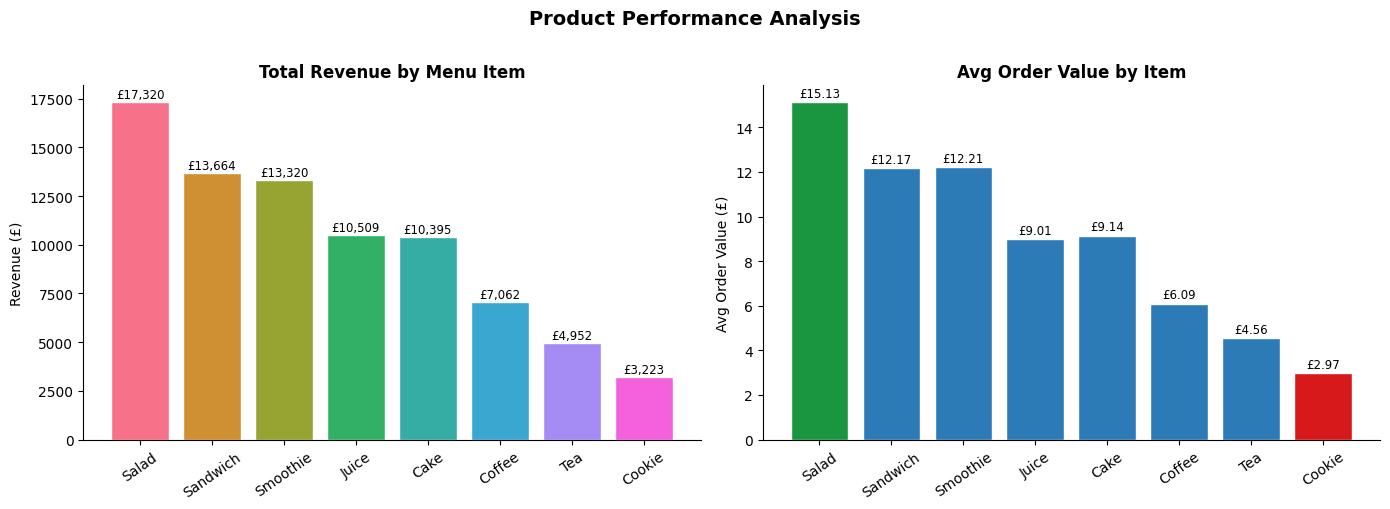

    Item  Total Revenue  Transactions  Avg Order Value  Revenue Share %
   Salad        17320.0          1145        15.126638             21.5
Sandwich        13664.0          1123        12.167409             17.0
Smoothie        13320.0          1091        12.208983             16.6
   Juice        10509.0          1167         9.005141             13.1
    Cake        10395.0          1137         9.142480             12.9
  Coffee         7062.0          1159         6.093184              8.8
     Tea         4951.5          1085         4.563594              6.2
  Cookie         3223.0          1087         2.965041              4.0


In [3]:
item_rev = df.groupby('Item')['Total Spent'].agg(['sum','count','mean']).reset_index()
item_rev.columns = ['Item','Total Revenue','Transactions','Avg Order Value']
item_rev = item_rev.sort_values('Total Revenue', ascending=False)
item_rev['Revenue Share %'] = (item_rev['Total Revenue'] / item_rev['Total Revenue'].sum() * 100).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — Revenue
bars = axes[0].bar(item_rev['Item'], item_rev['Total Revenue'],
                   color=sns.color_palette('husl', len(item_rev)), edgecolor='white', linewidth=1)
axes[0].set_title('Total Revenue by Menu Item', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=35)
for bar, val in zip(bars, item_rev['Total Revenue']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=8.5)

# Avg order value
colors2 = [GREEN if v == item_rev['Avg Order Value'].max() else RED if v == item_rev['Avg Order Value'].min() else ACCENT
           for v in item_rev['Avg Order Value']]
bars2 = axes[1].bar(item_rev['Item'], item_rev['Avg Order Value'], color=colors2, edgecolor='white', linewidth=1)
axes[1].set_title('Avg Order Value by Item', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Avg Order Value (£)')
axes[1].tick_params(axis='x', rotation=35)
for bar, val in zip(bars2, item_rev['Avg Order Value']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'£{val:.2f}', ha='center', va='bottom', fontsize=8.5)

plt.suptitle('Product Performance Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_product_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print(item_rev.to_string(index=False))


## Layer 3 — Revenue Over Time (Trend Analysis)

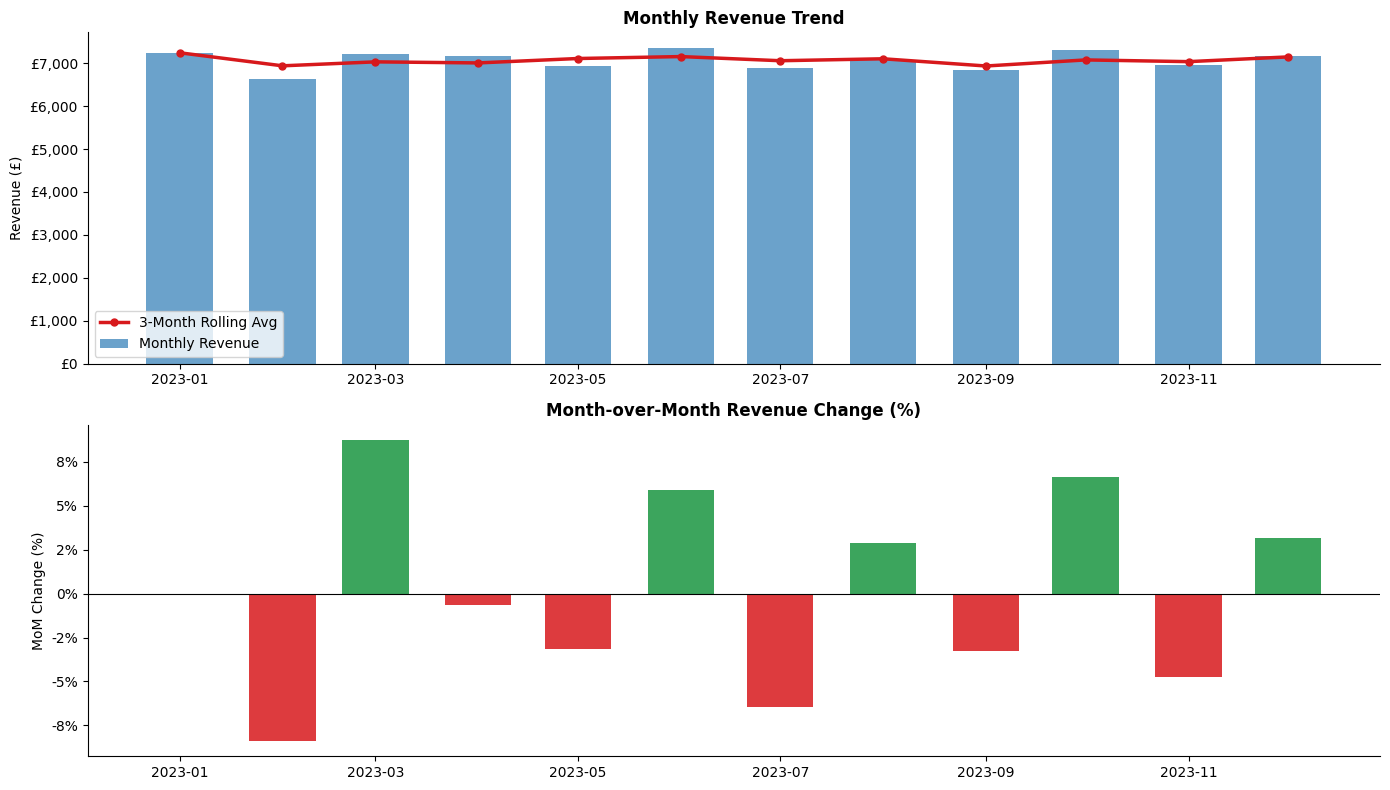

Transaction Date  Total Spent  MoM_Change
      2023-01-01       7242.0         NaN
      2023-02-01       6633.5   -8.402375
      2023-03-01       7214.5    8.758574
      2023-04-01       7168.0   -0.644535
      2023-05-01       6941.5   -3.159877
      2023-06-01       7350.0    5.884895
      2023-07-01       6877.5   -6.428571
      2023-08-01       7077.5    2.908033
      2023-09-01       6846.0   -3.270929
      2023-10-01       7302.0    6.660824
      2023-11-01       6957.0   -4.724733
      2023-12-01       7177.0    3.162283


In [4]:
# Monthly revenue trend
monthly = df.groupby(df['Transaction Date'].dt.to_period('M'))['Total Spent'].sum().reset_index()
monthly['Transaction Date'] = monthly['Transaction Date'].dt.to_timestamp()
monthly['Rolling_3M'] = monthly['Total Spent'].rolling(3, min_periods=1).mean()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Monthly bars + rolling avg
axes[0].bar(monthly['Transaction Date'], monthly['Total Spent'], color=ACCENT, alpha=0.7,
            width=20, label='Monthly Revenue')
axes[0].plot(monthly['Transaction Date'], monthly['Rolling_3M'], color=RED, linewidth=2.5,
             marker='o', markersize=5, label='3-Month Rolling Avg')
axes[0].set_title('Monthly Revenue Trend', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Revenue (£)')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))

# MoM % change
monthly['MoM_Change'] = monthly['Total Spent'].pct_change() * 100
colors_mom = [GREEN if x >= 0 else RED for x in monthly['MoM_Change'].fillna(0)]
axes[1].bar(monthly['Transaction Date'], monthly['MoM_Change'].fillna(0),
            color=colors_mom, alpha=0.85, width=20)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Month-over-Month Revenue Change (%)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('MoM Change (%)')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('fig_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Print monthly table
monthly['Total Spent'] = monthly['Total Spent'].round(2)
print(monthly[['Transaction Date','Total Spent','MoM_Change']].to_string(index=False))


## Layer 4 — Payment Method & Location Analysis

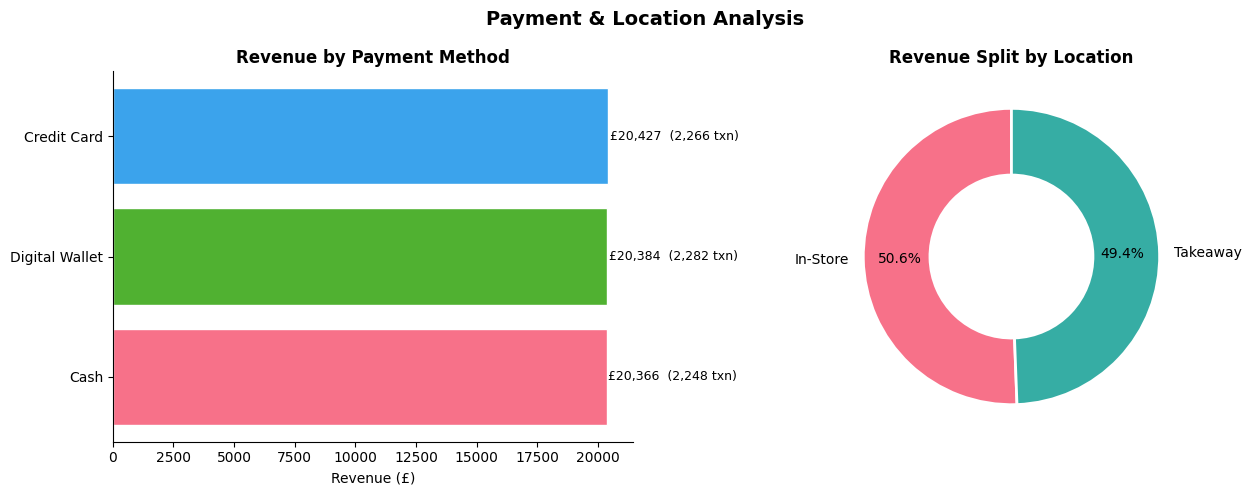


Payment Method Breakdown:
        Method  Revenue  Transactions
          Cash  20366.5          2248
Digital Wallet  20383.5          2282
   Credit Card  20427.0          2266

Location Breakdown:
Location  Revenue  Transactions
In-Store  27127.0          3003
Takeaway  26487.5          3009


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Payment method
pay = df.groupby('Payment Method')['Total Spent'].agg(['sum','count']).reset_index()
pay.columns = ['Method','Revenue','Transactions']
pay = pay.sort_values('Revenue', ascending=True)
axes[0].barh(pay['Method'], pay['Revenue'], color=sns.color_palette('husl', len(pay)), edgecolor='white')
axes[0].set_title('Revenue by Payment Method', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Revenue (£)')
for i, (rev, txn) in enumerate(zip(pay['Revenue'], pay['Transactions'])):
    axes[0].text(rev + 50, i, f'£{rev:,.0f}  ({txn:,} txn)', va='center', fontsize=9)

# Location
loc = df.groupby('Location')['Total Spent'].agg(['sum','count']).reset_index()
loc.columns = ['Location','Revenue','Transactions']
loc = loc.sort_values('Revenue', ascending=False)
wedge_props = dict(width=0.45, edgecolor='white', linewidth=2)
axes[1].pie(loc['Revenue'], labels=loc['Location'], autopct='%1.1f%%',
            colors=sns.color_palette('husl', len(loc)), wedgeprops=wedge_props,
            startangle=90, pctdistance=0.75)
axes[1].set_title('Revenue Split by Location', fontweight='bold', fontsize=12)

plt.suptitle('Payment & Location Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_payment_location.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPayment Method Breakdown:")
print(pay.to_string(index=False))
print("\nLocation Breakdown:")
print(loc.to_string(index=False))


## Layer 5 — Day-of-Week & Hourly Patterns

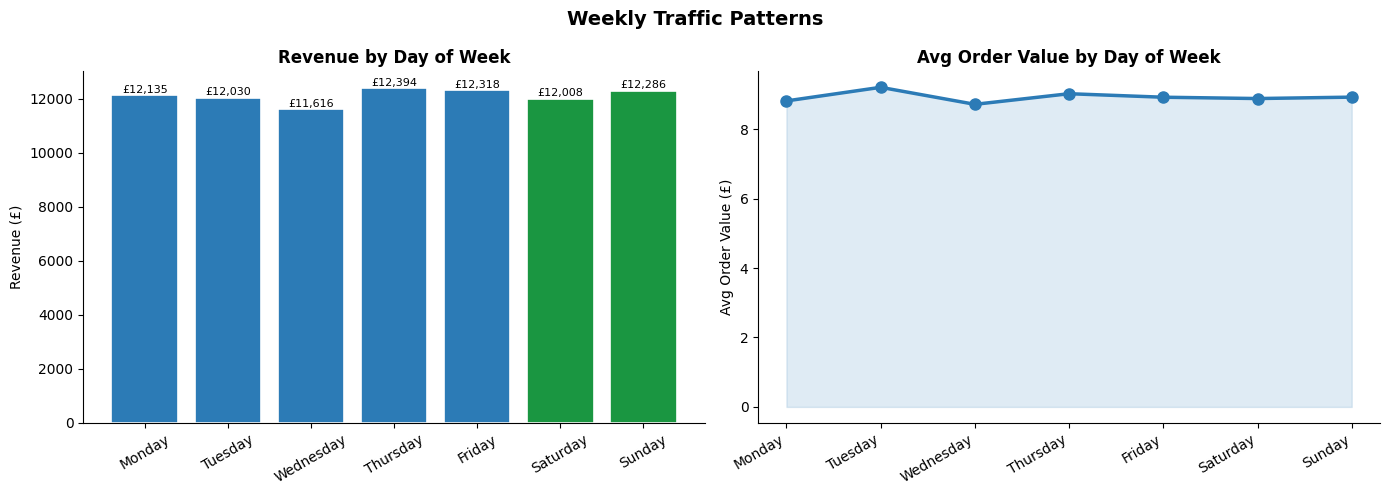

      Day  Revenue  Transactions  Avg Per Txn
   Monday  12135.0          1377     8.812636
  Tuesday  12030.5          1307     9.204667
Wednesday  11616.5          1333     8.714554
 Thursday  12394.0          1374     9.020378
   Friday  12317.5          1381     8.919261
 Saturday  12007.5          1352     8.881287
   Sunday  12285.5          1377     8.921932


In [6]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('Day of Week')['Total Spent'].agg(['sum','count']).reset_index()
dow.columns = ['Day','Revenue','Transactions']
dow['Day'] = pd.Categorical(dow['Day'], categories=dow_order, ordered=True)
dow = dow.sort_values('Day')
dow['Avg Per Txn'] = dow['Revenue'] / dow['Transactions']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars = axes[0].bar(dow['Day'], dow['Revenue'],
                   color=[GREEN if d in ['Saturday','Sunday'] else ACCENT for d in dow['Day']],
                   edgecolor='white', linewidth=1.2)
axes[0].set_title('Revenue by Day of Week', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, dow['Revenue']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'£{val:,.0f}', ha='center', va='bottom', fontsize=8)

axes[1].plot(dow['Day'], dow['Avg Per Txn'], marker='o', color=ACCENT, linewidth=2.5, markersize=8)
axes[1].fill_between(range(len(dow)), dow['Avg Per Txn'], alpha=0.15, color=ACCENT)
axes[1].set_xticks(range(len(dow)))
axes[1].set_xticklabels(dow['Day'], rotation=30, ha='right')
axes[1].set_title('Avg Order Value by Day of Week', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Avg Order Value (£)')

plt.suptitle('Weekly Traffic Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_dow_patterns.png', dpi=150, bbox_inches='tight')
plt.show()
print(dow.to_string(index=False))


## Layer 6 — Product × Location Heatmap

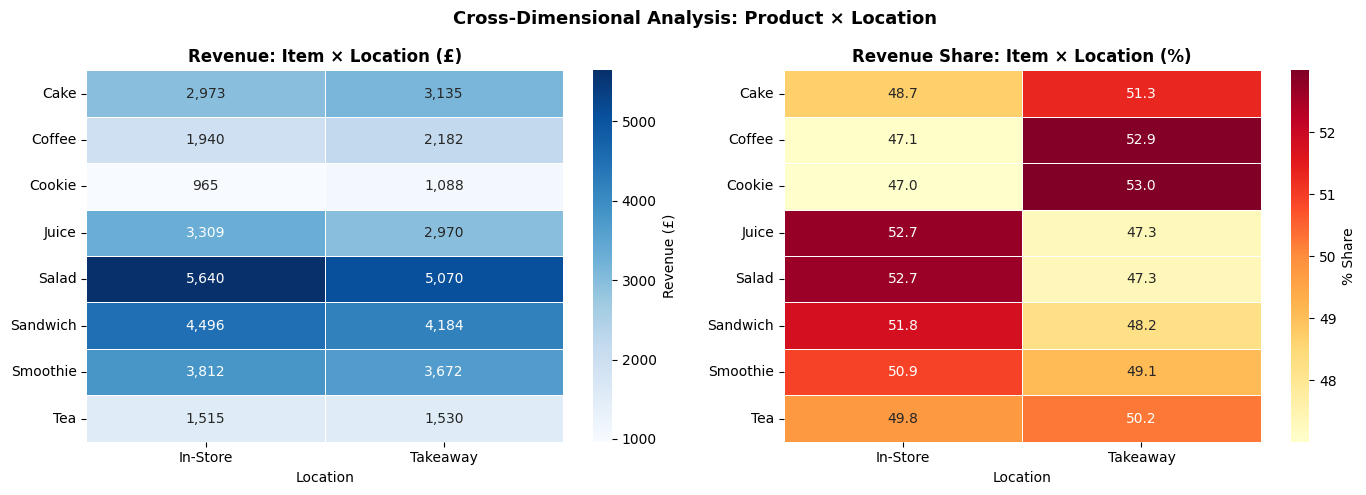

In [7]:
pivot = df.groupby(['Item','Location'])['Total Spent'].sum().unstack(fill_value=0)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100  # % share per item

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pivot, annot=True, fmt=',.0f', cmap='Blues', linewidths=0.5,
            ax=axes[0], cbar_kws={'label': 'Revenue (£)'})
axes[0].set_title('Revenue: Item × Location (£)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('')

sns.heatmap(pivot_pct, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            ax=axes[1], cbar_kws={'label': '% Share'})
axes[1].set_title('Revenue Share: Item × Location (%)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('')

plt.suptitle('Cross-Dimensional Analysis: Product × Location', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_item_location_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Layer 7 — Quantity Distribution & Revenue Distribution

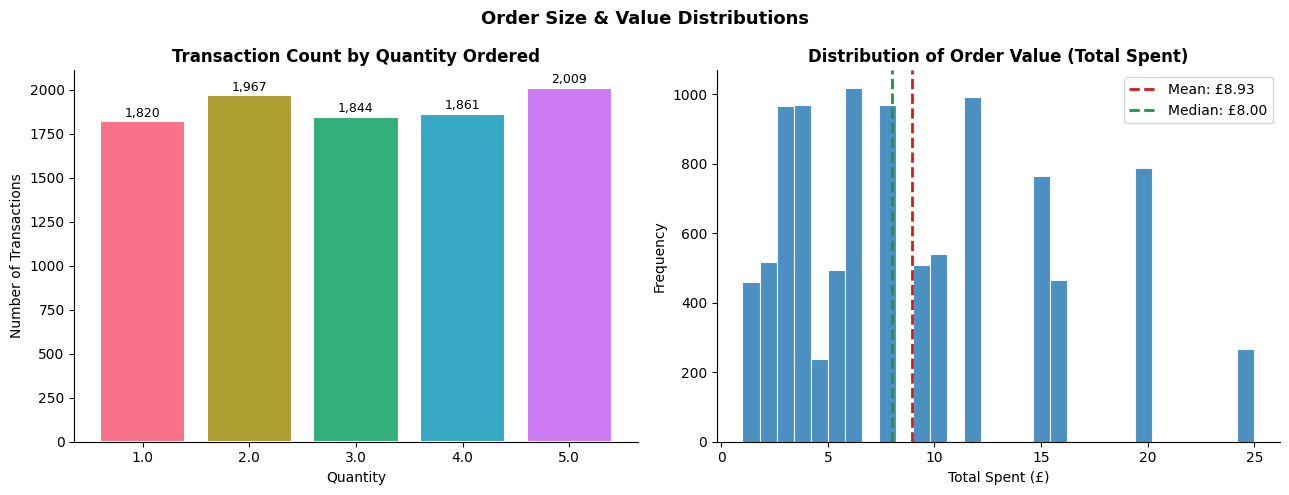

Revenue Stats:
count    9960.00
mean        8.93
std         6.00
min         1.00
25%         4.00
50%         8.00
75%        12.00
max        25.00
Name: Total Spent, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Quantity dist
qty_dist = df['Quantity'].value_counts().sort_index()
bars = axes[0].bar(qty_dist.index.astype(str), qty_dist.values,
                   color=sns.color_palette('husl', len(qty_dist)), edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Count by Quantity Ordered', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Quantity')
axes[0].set_ylabel('Number of Transactions')
for bar, val in zip(bars, qty_dist.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Revenue distribution
axes[1].hist(df['Total Spent'].dropna(), bins=30, color=ACCENT, edgecolor='white', linewidth=0.8, alpha=0.85)
axes[1].axvline(df['Total Spent'].mean(), color=RED, linestyle='--', linewidth=2,
                label=f"Mean: £{df['Total Spent'].mean():.2f}")
axes[1].axvline(df['Total Spent'].median(), color=GREEN, linestyle='--', linewidth=2,
                label=f"Median: £{df['Total Spent'].median():.2f}")
axes[1].set_title('Distribution of Order Value (Total Spent)', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Total Spent (£)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Order Size & Value Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Revenue Stats:\n{df['Total Spent'].describe().round(2)}")
